In [1]:
# Import all necessary libraries.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import GridSearchCV
from matplotlib.colors import ListedColormap
from IPython.display import Image  
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc
from scipy import stats
import pydot
from sklearn.base import clone
from scipy.stats import mode
import seaborn as sns

In [2]:
# Create datase.
X, y = make_moons(n_samples = 10000, noise = 0.4, random_state=42)

In [3]:
# Split the dataset.
X_train, X_test, y_train, y_test = train_test_split (X, y, test_size=0.25, random_state=42)

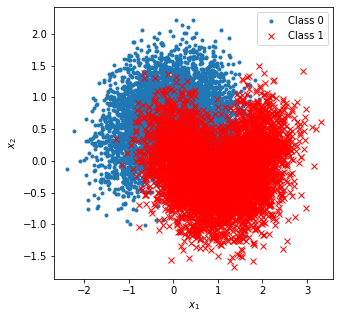

In [4]:
idx0 = np.argwhere(y == 0)
idx1 = np.argwhere(y == 1)

fig = plt.figure(figsize=(5,5))
plt.plot(X[idx0,0], X[idx0,1], '.', label='Class 0')
plt.plot(X[idx1,0], X[idx1,1], 'rx', label='Class 1')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.legend()
plt.show()

In [5]:
clf = DecisionTreeClassifier(random_state=42, min_samples_leaf=3, max_leaf_nodes=34)

forest = [clone(clf) for _ in range(1000)]

In [6]:
scores_b = []
# Split em 1000 subconjuntos
rs = ShuffleSplit(n_splits=1000, test_size=len(X_train) - 100, random_state=42)

accuracy_single = []
inc = 0
y_pred = np.empty([1000, len(X_test)], dtype=np.uint8)
for train_index, test_index in rs.split(X_train):
    
    X_mini_train = X_train[train_index]
    y_mini_train = y_train[train_index]
    
    X_mini_test = X_train[test_index]
   
    forest[inc].fit(X_mini_train, y_mini_train)
    
    y_pred[inc] = forest[inc].predict(X_test)
    
    # Calculate and return the accuracy on the test data 
    accuracy_single.append(accuracy_score(y_test, y_pred[inc]))
    
    inc += 1
    
print('4c) Acurácia do conjunto de teste:', np.mean(accuracy_single)*100, '%')

4c) Acurácia do conjunto de teste: 80.0144 %


In [7]:
y_pred_majority_votes, n_votes = mode(y_pred, axis=0)
print('4d) Medição da performance do classificador no conjunto de teste:', accuracy_score(y_test, y_pred_majority_votes.reshape([-1]))*100, '%')

4d) Medição da performance do classificador no conjunto de teste: 86.92 %
